# Base Line Models

## Importing Engineered Features

In [129]:
import pandas as pd

In [130]:
df = pd.read_csv('engineered_features.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,account_age_bucket,amount_bucket,ip_risk_score_bucket,device_trust_score_bucket,night_hours,account_age_breakdown,amount_breakdown,ip_risk,device_risk
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,91-365 days,100-500,<0.3,0.5-0.7,0,matured,low,low,medium
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,>365 days,100-500,0.5-0.7,0.3-0.5,0,matured,low,medium,medium
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,>365 days,100-500,0.3-0.5,>0.8,0,matured,low,medium,high
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,91-365 days,<100,0.5-0.7,0.5-0.7,0,matured,low,medium,medium
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,91-365 days,100-500,<0.3,>0.8,0,matured,low,low,high


In [131]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


In [132]:
print(df['timestamp'].dtype)

object


In [133]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## More Engineered Features

In [134]:
df['is_high_velocity_1h'] = (df['txn_velocity_1h'] < 4).astype(int)

In [135]:
df['is_high_velocity_24h'] = (df['txn_velocity_24h'] < 4).astype(int)

## Creating Train and Test Dataset

In [136]:
print(df['timestamp'].dtype)

datetime64[ns, UTC]


In [137]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'home_country_cleaned',
       'hour', 'day_of_week', 'month', 'is_weekend', 'account_age_bucket',
       'amount_bucket', 'ip_risk_score_bucket', 'device_trust_score_bucket',
       'night_hours', 'account_age_breakdown', 'amount_breakdown', 'ip_risk',
       'device_risk', 'is_high_velocity_1h', 'is_high_velocity_24h'],
      dtype='object')

In [138]:
df = df.sort_values(by='timestamp').reset_index(drop=True)

In [139]:
columns_to_drop = ['transaction_id',
                   'timestamp',
                   'customer_id',
                   'exchange_rate_src_to_dest',
                   'device_id',
                   'ip_risk_score',
                   'txn_velocity_1h',
                   'txn_velocity_24h',
                   'account_age_days',
                   ]
df.drop(columns=columns_to_drop, inplace=True)

In [140]:
all_features = df.columns.tolist()
all_features.remove('is_fraud')
all_features

['home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'kyc_tier',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'corridor_risk',
 'home_country_cleaned',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'account_age_bucket',
 'amount_bucket',
 'ip_risk_score_bucket',
 'device_trust_score_bucket',
 'night_hours',
 'account_age_breakdown',
 'amount_breakdown',
 'ip_risk',
 'device_risk',
 'is_high_velocity_1h',
 'is_high_velocity_24h']

In [141]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} rows {(train_df['is_fraud']).sum()} fraud, {(train_df['is_fraud']).mean():.3f} rate of fraud")
print(f"Test: {len(test_df)} rows {(test_df['is_fraud']).sum()} fraud, {(test_df['is_fraud']).mean():.3f} rate of fraud")

Train: 8605 rows 675 fraud, 0.078 rate of fraud
Test: 2152 rows 307 fraud, 0.143 rate of fraud


In [142]:
X_train = train_df[all_features]
y_train = train_df['is_fraud']

X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (8605, 32), y_train: (8605,)
X_test: (2152, 32), y_test: (2152,)


## Hot Encoding and Standard Scaling

In [143]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [144]:
numerical_features.remove('is_fraud')

In [145]:
len(categorical_features) + len(numerical_features)

30

In [146]:
remaining_features = list(
    set(all_features) - set(categorical_features) - set(numerical_features)
)
remaining_features

['location_mismatch', 'new_device']

In [147]:
print(df['location_mismatch'].dtype)

bool


In [186]:
boolean_features = ['location_mismatch', 'new_device']

In [148]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [187]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ])


X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"Original features: {len(all_features)}, After encoding: {X_train_preprocessed.shape[1]}")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


X_train_preprocessed: (8605, 8522)
Original features: 32, After encoding: 8522


In [150]:
df.isna().sum()

,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0
new_device,0
ip_address,0
ip_country,0


## Training Baseline Models

In [188]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)

y_pred_lr = lr_model.predict(X_test_preprocessed)
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]

print("Logistic Regression Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lr):.2f}")

Logistic Regression Results:

Confusion Matrix:
[[1829   16]
 [  19  288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.95      0.94      0.94       307

    accuracy                           0.98      2152
   macro avg       0.97      0.96      0.97      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.98


In [189]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.25, 0.4, 0.6, 0.65, 0.8]



In [234]:
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1845
           1       0.39      0.98      0.55       307

    accuracy                           0.77      2152
   macro avg       0.69      0.86      0.70      2152
weighted avg       0.91      0.77      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.69      0.95      0.80       307

    accuracy                           0.93      2152
   macro avg       0.84      0.94      0.88      2152
weighted avg       0.95      0.93      0.94      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1845
           1       0.88      0.95      0.91       307

    accuracy                           0.97      2152
   macro avg       0.94      0.96      0.95      2152
weighted avg       0.98     

In [191]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    max_depth=10,
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    n_jobs=1
    )
rf_model.fit(X_train_preprocessed, y_train)

#Predict on test
y_pred_rf = rf_model.predict(X_test_preprocessed)
y_proba_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("Random Forest Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_rf):.2f}")

Random Forest Results:

Confusion Matrix:
[[1843    2]
 [  24  283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152


ROC AUC Score:, 0.98


In [235]:
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1845
           1       0.14      1.00      0.25       307

    accuracy                           0.14      2152
   macro avg       0.07      0.50      0.12      2152
weighted avg       0.02      0.14      0.04      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.63      0.77      1845
           1       0.31      0.98      0.47       307

    accuracy                           0.68      2152
   macro avg       0.65      0.81      0.62      2152
weighted avg       0.90      0.68      0.73      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.83      0.94      0.88       307

    accuracy                           0.96      2152
   macro avg       0.91      0.95      0.93      2152
weighted avg       0.97     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [193]:
from xgboost import XGBClassifier

scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

xgb_model.fit(X_train_preprocessed, y_train)

#Predict at test
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_proba_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("XGBoost Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_xgb):.2f}")

XGBoost Results:

Confusion Matrix:
[[1824   21]
 [  22  285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


In [236]:
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1845
           1       0.38      0.96      0.55       307

    accuracy                           0.77      2152
   macro avg       0.69      0.85      0.70      2152
weighted avg       0.90      0.77      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.68      0.94      0.79       307

    accuracy                           0.93      2152
   macro avg       0.83      0.93      0.87      2152
weighted avg       0.94      0.93      0.93      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.85      0.93      0.89       307

    accuracy                           0.97      2152
   macro avg       0.92      0.95      0.93      2152
weighted avg       0.97     

In [195]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    )

lgbm_model.fit(X_train_preprocessed, y_train)

#Predict as test
y_pred_lgbm = lgbm_model.predict(X_test_preprocessed)
y_proba_lgbm = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("LightGBM Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lgbm):.2f}")

LightGBM Results:

Confusion Matrix:
[[1826   19]
 [  24  283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.94      0.92      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [196]:
for t in thresholds:
    y_pred_t = (y_proba_lgbm >= t).astype(int)
    print(
        f"Threshold {t:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_t):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_t):.3f} | "
        f"F1: {f1_score(y_test, y_pred_t):.3f}"
    )

Threshold 0.10 | Precision: 0.455 | Recall: 0.945 | F1: 0.614
Threshold 0.25 | Precision: 0.748 | Recall: 0.928 | F1: 0.828
Threshold 0.40 | Precision: 0.863 | Recall: 0.925 | F1: 0.893
Threshold 0.60 | Precision: 0.969 | Recall: 0.922 | F1: 0.945
Threshold 0.65 | Precision: 0.979 | Recall: 0.922 | F1: 0.950
Threshold 0.80 | Precision: 0.993 | Recall: 0.922 | F1: 0.956


## Feature Importance and SHAP Interpretability

### Logistic Feature Importance

In [200]:
lr_coeffecients = lr_model.coef_[0]
lr_coeffecients

array([-0.30189635,  0.06787282,  0.47206758, ..., -0.24671581,
        0.95234666, -0.67180154])

In [201]:
print(len(lr_coeffecients))
print(len(all_features))


8522
32


In [184]:
cat_encoder = preprocessor.named_transformers_['cat']

cat_features = list(
    cat_encoder.get_feature_names_out(categorical_features)
)


In [198]:
encoded_features = numerical_features + cat_features + boolean_features
len(encoded_features)

8522

In [202]:
feature_importance = pd.DataFrame({
    'features': encoded_features,
    'coefficient': lr_coeffecients
})

In [203]:
feature_importance['abs_coef'] = feature_importance['coefficient'].abs()


In [204]:
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

In [205]:
feature_importance.head(15)


,features,coefficient,abs_coef
2976,ip_address_179.17.146.251,3.996764,3.996764
4740,ip_address_224.224.80.254,3.535297,3.535297
7191,ip_address_62.123.91.131,3.526898,3.526898
2569,ip_address_168.175.194.23,3.510534,3.510534
958,ip_address_124.240.98.190,3.468381,3.468381
1233,ip_address_131.60.43.161,3.398820,3.398820
849,ip_address_121.186.93.199,3.366773,3.366773
6647,ip_address_48.38.194.193,3.347527,3.347527
1444,ip_address_137.172.155.222,3.327389,3.327389
5191,ip_address_236.181.218.56,3.224402,3.224402


In [213]:
def get_original_feature(col):
    if col in numerical_features or col in boolean_features:
        return col

    for orig in categorical_features:
        if col.startswith(orig + '_'):
            return orig
    return col


In [214]:
feature_importance['original_feature'] = (
    feature_importance['features']
    .apply(get_original_feature)
)


In [215]:
aggregated_importance = (
    feature_importance
    .groupby('original_feature')['abs_coef']
    .sum()
    .reset_index()
    .sort_values(by='abs_coef', ascending=False)
)


In [216]:
aggregated_importance

,original_feature,abs_coef
17,ip_address,701.182340
18,ip_country,3.548164
15,home_country,2.949736
1,account_age_bucket,2.726414
10,dest_currency,2.678671
24,kyc_tier,2.491474
13,device_trust_score_bucket,2.134318
20,ip_risk_score_bucket,1.890999
3,amount_bucket,1.611648
2,amount_breakdown,1.210200


### Random Forest Feature Importance

In [217]:
rf_importances = rf_model.feature_importances_


In [218]:
len(rf_importances) == X_train_preprocessed.shape[1]


True

In [219]:
rf_feature_importance = pd.DataFrame({
    'feature': encoded_features,
    'importance': rf_importances
})

In [220]:
rf_feature_importance = rf_feature_importance.sort_values(
    by='importance',
    ascending=False
)

rf_feature_importance.head(15)


,feature,importance
13,is_high_velocity_24h,0.068353
3,device_trust_score,0.058379
5,risk_score_internal,0.057820
4,chargeback_history_count,0.050907
8506,ip_risk_score_bucket_>0.8,0.049642
8520,location_mismatch,0.046148
12,is_high_velocity_1h,0.043278
0,amount_src,0.040048
8509,device_trust_score_bucket_<0.3,0.039360
1,amount_usd,0.035147


In [221]:
rf_feature_importance['original_feature'] = (
    rf_feature_importance['feature']
    .apply(get_original_feature)
)


In [222]:
rf_aggregated_importance = (
    rf_feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values(by='importance', ascending=False)
)


In [223]:
rf_aggregated_importance.head(10)


,original_feature,importance
1,account_age_bucket,0.083362
20,ip_risk_score_bucket,0.079909
13,device_trust_score_bucket,0.072295
22,is_high_velocity_24h,0.068353
12,device_trust_score,0.058379
29,risk_score_internal,0.057820
7,chargeback_history_count,0.050907
2,amount_breakdown,0.050742
25,location_mismatch,0.046148
21,is_high_velocity_1h,0.043278


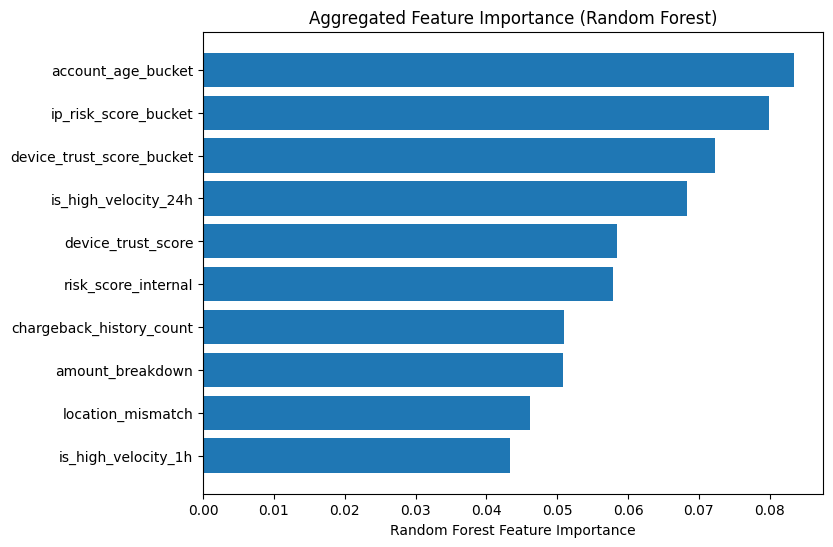

In [224]:
import matplotlib.pyplot as plt

top_rf = rf_aggregated_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_rf['original_feature'], top_rf['importance'])
plt.xlabel('Random Forest Feature Importance')
plt.title('Aggregated Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


### XGBoost Feature Importance

In [225]:
import shap

explainer = shap.TreeExplainer(xgb_model)


In [226]:
shap_values = explainer.shap_values(X_test_preprocessed)


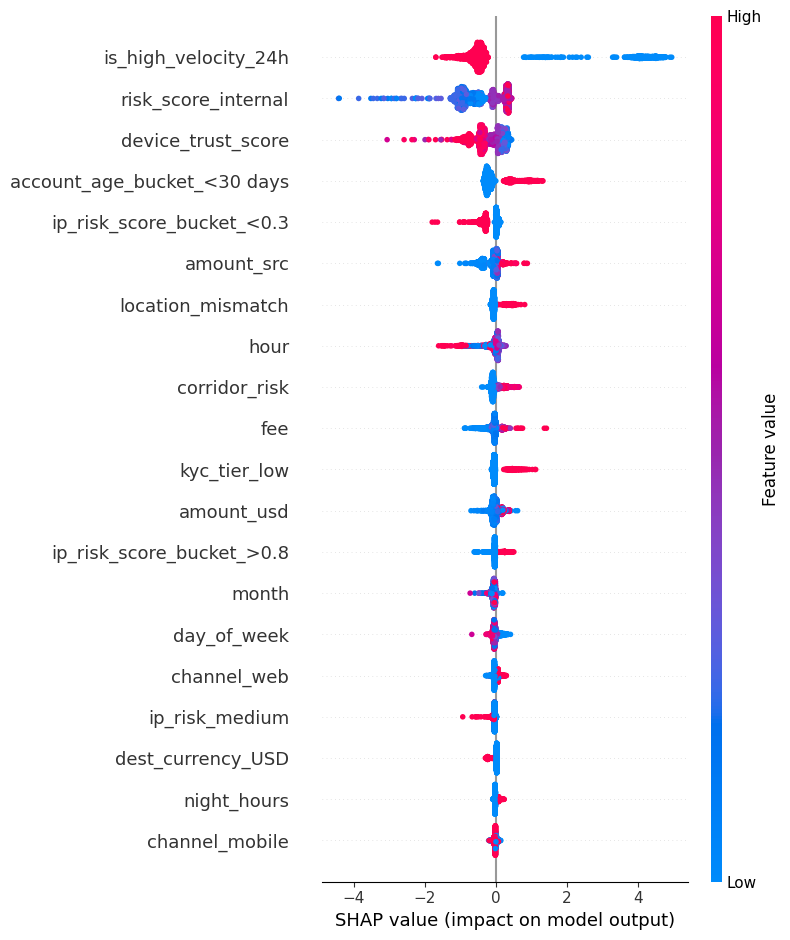

In [227]:
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=encoded_features
)


# Comparison Notes

## Threshold Selection

Thresholds of between 0.1 to 0.8 were tested to select the best that gave best balance between recall and precision, below is a table for each baseline model across the different thresholds

### Logistic Regression

| Threshold | Precision | Recall | F1-score |
|----------|-----------|--------|----------|
| 0.10 | 0.385  | 0.977  | 0.552  |
| 0.25 |  0.688| 0.954 | 0.799 |
| 0.40 | 0.879 | 0.948 | 0.912 |
| 0.50 |  0.95|  0.94| 0.94 |
| 0.60 | 0.983 | 0.932 |  0.957|
| 0.65 |  0.990| 0.932  | 0.960 |
| 0.80 | 1.000 | 0.928  | 0.963 |


### Random Forest

| Threshold | Precision | Recall | F1-score |
|----------|-----------|--------|----------|
| 0.10 | 0.14  | 1.00   | 0.25  |
| 0.25 |  0.25| 0.98 | 0.47 |
| 0.40 | 0.83  | 0.94 | 0.88 |
| 0.50 |  0.99 |  0.92| 0.96 |
| 0.60 | 1.00 | 0.92 |  0.96|
| 0.65 |  1.00| 0.92  | 0.96 |
| 0.80 | 1.000 | 0.73  | 0.84 |

### XGBoost Tree

| Threshold | Precision | Recall | F1-score |
|----------|-----------|--------|----------|
| 0.10 | 0.38 | 0.96  | 0.55  |
| 0.25 |  0.68  | 0.94       | 0.79 |
| 0.40 | 0.85  | 0.93 | 0.89 |
| 0.50 |  0.99 |  0.92| 0.96 |
| 0.60 | 0.96       | 0.93    |  0.94|
| 0.65 |  0.97 |   0.93   |    0.95 |
| 0.80 | 1.00 | 0.93  | 0.96 |

Across all three baseline models, thresholds below 0.5 consistently resulted in precision values below 90%, indicating an unacceptably high rate of false positives for this task. As the threshold increased from 0.5 to 0.65, precision improved substantially (ranging from 0.95 to 1.0) while recall remained relatively stable between 0.92 and 0.94.

Among these values, a threshold of 0.6 provided the most favorable operating point. At this threshold, precision reached its maximum (≈1.0) with minimal or no degradation in recall. For example, in the best-performing model (Random Forest), precision increased from 0.99 at a threshold of 0.5 to 1.0 at 0.6, while recall remained constant at 0.92. This pattern was consistently observed across all three models.

Given the objective of minimizing false positives while preserving high recall, 0.6 was selected as the recommended probability thresholdranging between 0.95 and 1 across these thresholds for all three models and recall 0.92 and 0.94, however the best performing threshold is 0.6 where precision goes high with the tradeoff in recall for minimum, for example for our best performing model Random Forest at threshold 0.5 with precision 0.99 and recall 0.92, with threshold 0.6 precision goes to 1 and recall remains at 0.92, this behavior is recorded across three models, making 0.6 the recommended threshold for model.

## Interpretable Features

### Logistic Regression Coeffecients
Aggregated logistic regression coefficients indicate that IP-based features are the strongest contributors to fraud prediction, highlighting the importance of network and geolocation signals. Account age, device trust, transaction amount patterns, and location consistency also play significant roles, while contextual features such as channel, currency, and velocity indicators provide supporting signals. Lower-ranked temporal and raw amount features contribute minimally once higher-level engineered features are included.


### XGBoost SHAP Features
The SHAP summary plot for the XGBoost model highlights velocity-based indicators, device trust, account age, and IP risk as the strongest contributors to fraud prediction. High transaction velocity and young account age strongly increase fraud likelihood, while high device trust and low IP risk push predictions toward non-fraud. Transaction amount and location mismatch provide additional discriminatory power, primarily through non-linear interactions


### Summary
These findings are largely consistent with the logistic regression coefficient analysis, where IP-based and behavioral features also emerged as dominant signals. However, XGBoost distributes importance more evenly across multiple feature groups and captures interaction effects that are not represented in the linear model. This suggests that while both models rely on similar underlying risk drivers, XGBoost achieves a more nuanced and robust decision boundary.